## IPL 2022 Capstone Project
-> The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

-> These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

- **date** : string
- **venue** : string
- **stage** : string
- **team1** : string
- **team2** : string
- **toss_winner** : string
- **toss_decision** : string
- **first_ings_score** : integer
- **second_ings_score** : integer
- **match_winner** : string
- **won_by** : string
- **margin** : integer
- **player_of_the_match** : string
- **top_scorer** : string
- **highscore** : integer
- **best_bowling** : string
- **best_bowling_fgure** : string
- **gure** : string

## Loading the Libraries and Dataset

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("IPL.csv")

df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [6]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [7]:
# check the size of rows and columns of the dataset
df.shape

(74, 20)

In [9]:
# Now let's see how many columns have null values in total
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### Now, Here come some basic questions

1. which team won the most matches

Text(0.5, 1.0, 'Most matches win by team')

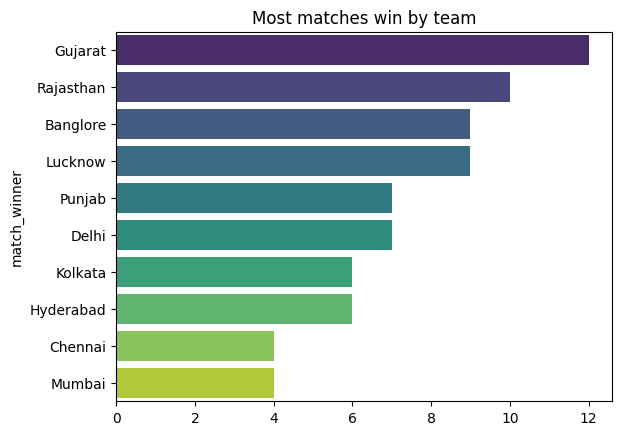

In [11]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index, x = match_wins.values, palette = "viridis")
plt.title("Most matches win by team")

2. Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

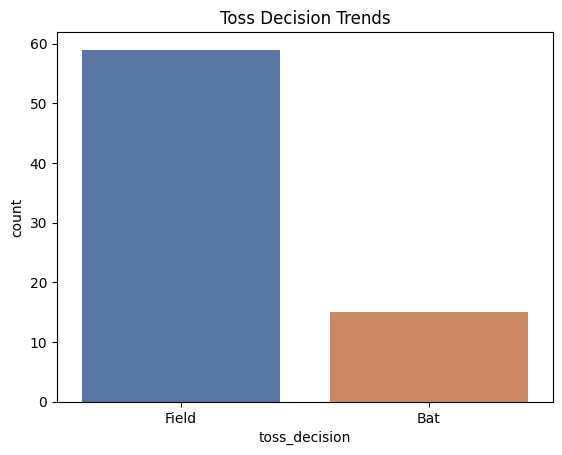

In [19]:
sns.countplot(x = df['toss_decision'], palette = 'deep')
plt.title('Toss Decision Trends')

3. Toss Winner vs Match Winner

In [24]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

In [23]:
# other approach 
percentage = (df['toss_winner'] == df['match_winner']).mean() * 100
percentage

np.float64(48.64864864864865)

4. How do teams win?(Runs vs Wickets)

Text(0.5, 1.0, 'Wins(runs vs wickets)')

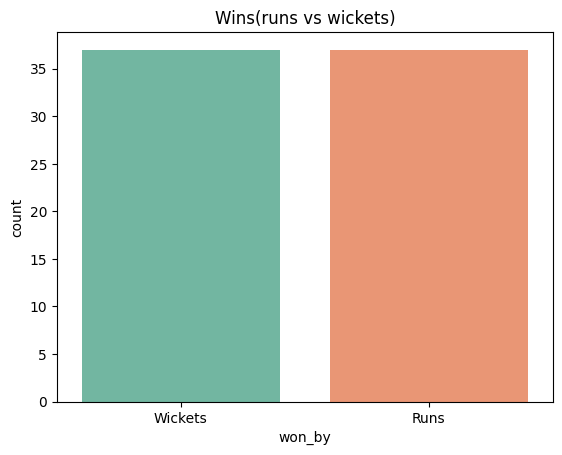

In [27]:
sns.countplot(x = df['won_by'], palette = 'Set2')
plt.title('Wins(runs vs wickets)')

### Key Player Performance

In [31]:
# Most "Player of the Match" Awards
count = df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top10 most win player of the match')

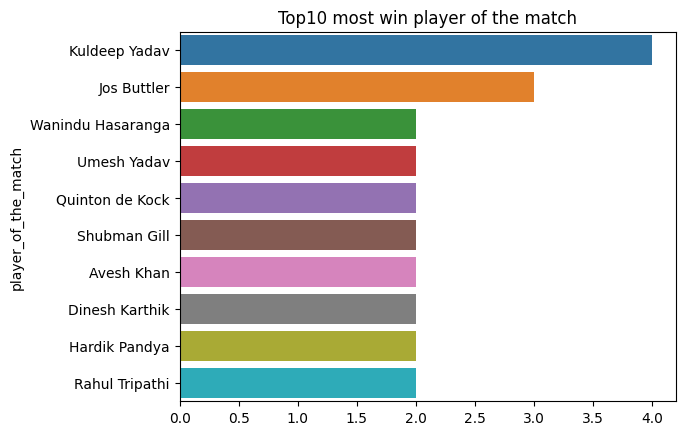

In [34]:
sns.barplot(x = count.values , y = count.index , palette = 'tab10')
plt.title("Top10 most win player of the match")

In [37]:
# 2 Top Scorers
highscr = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)
highscr

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

Text(0.5, 1.0, 'two top scorer')

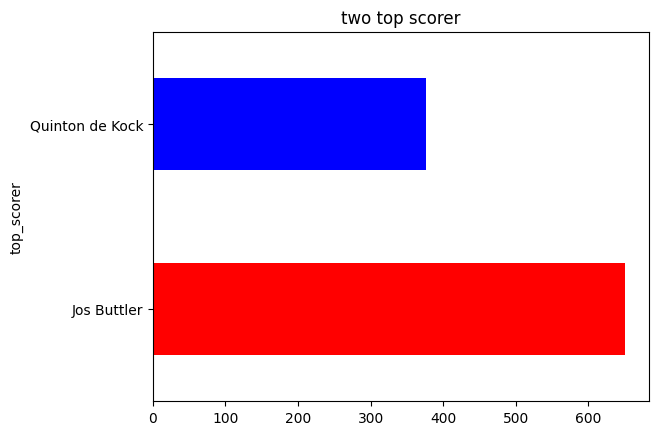

In [49]:
highscr.plot(kind= 'barh', color=['red', 'blue']) # using matplotlib
plt.title("two top scorer")


<Axes: ylabel='top_scorer'>

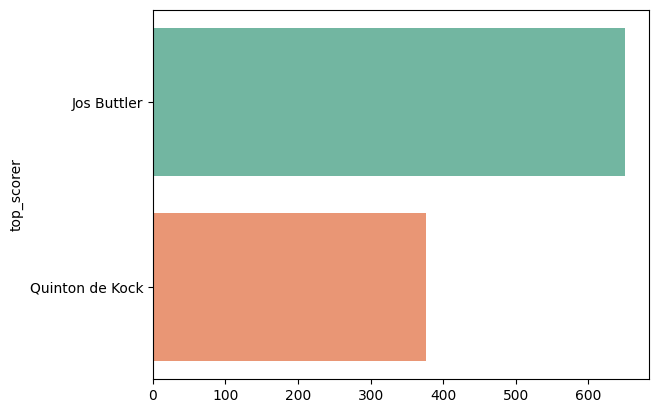

In [47]:
sns.barplot(x = highscr.values, y = highscr.index, palette = 'Set2') # using seaborn

<Axes: ylabel='best_bowling'>

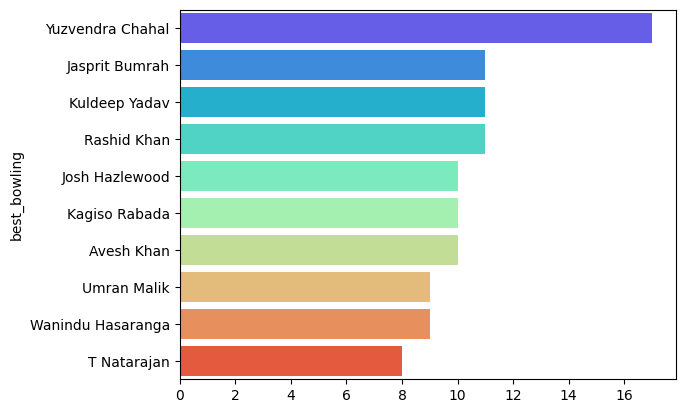

In [66]:
# 10 best bowling figure
df['highest_wicket'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wicket'] = df['highest_wicket'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending = False).head(10)
sns.barplot(x = top_bowlers.values, y = top_bowlers.index, palette = 'rainbow')

## Venue Analysis

<Axes: ylabel='venue'>

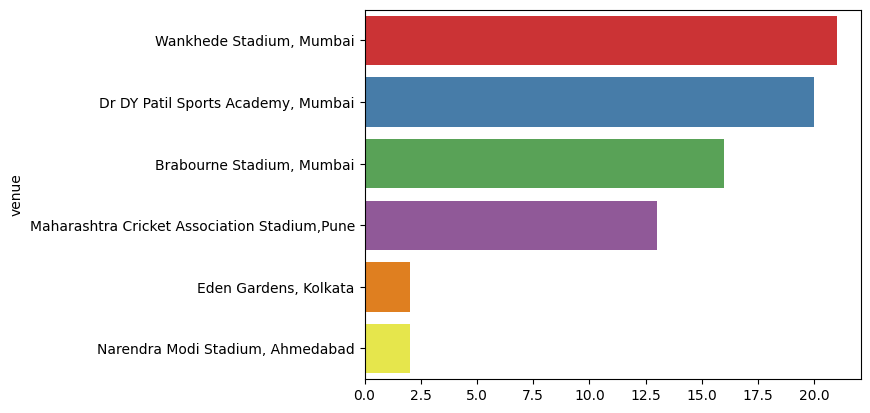

In [76]:
# Most Matches played by venue
venue_count = df['venue'].value_counts()
sns.barplot(x = venue_count.values, y = venue_count.index, palette = 'Set1')

## Custom Questions & Insights

In [78]:
# Who won the highest margin by runs?
df[df['won_by']=='Runs'].sort_values(by = 'margin', ascending = False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


In [79]:
#which player had the highest individual score?
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [82]:
#which bowler had the best bowling figures?
df[df['highest_wicket'] == df['highest_wicket'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
